# RESOLUCIÓN PRÁCTICA ML

In [1]:
#Importo todo lo que necesito para realizar la práctica.

import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import TargetEncoder
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
!pip install xgboost
from xgboost import XGBRegressor 

In [2]:
#CARGO EL CSV
airbnb_practica = pd.read_csv("airbnb-listings-extract.csv", engine='python', sep=None)

#HAGO UN PRIMER BARRIDO DE TODAS LAS COLUMNAS Y SELECCIONO LAS QUE TIENEN VALOR PREDICTIVO, ELIMINANDO INFORMACIÓN NO IMPORTANTE.
columnas_ok_practica = ['Neighbourhood Cleansed','City', 'Country', 'Property Type', 'Room Type', 'Accommodates', 'Bathrooms', 'Price', 'Security Deposit', 'Cleaning Fee',
                         'Guests Included','Extra People', 'Availability 365', 'Review Scores Rating']
airbnb_practica_v2 = airbnb_practica[columnas_ok_practica]

#COLOCO LA COLUMNA PRICE EN LA PRIMERA COLUMNA PARA QUE SEA MÁS CÓMODO.
cols = ['Price'] + [col for col in airbnb_practica_v2.columns if col != 'Price']
airbnb_practica_v2 = airbnb_practica_v2[cols]

#HAGO LA DIVISIÓN TRAIN/TEST Y CREO LOS DOS NUEVOS CSVs CON ESTA DIVISIÓN
train, test = train_test_split(airbnb_practica_v2, test_size=0.2, shuffle=True, random_state=42)
train.to_csv("airbnb_practica_train.csv", sep=';', decimal='.', index=False)
test.to_csv("airbnb_practica_test.csv", sep=';', decimal='.', index=False)

# 4_Cargamos el csv de train y hacemos el análisis exploratorio con él
airbnb_practica_train = pd.read_csv("airbnb_practica_train.csv", engine='python', sep=None)
airbnb_practica_test = pd.read_csv("airbnb_practica_test.csv", engine='python', sep=None)

In [ ]:
#CARGO LA SELECCIÓN DE TRAIN Y HAGO LA EXPLORACIÓN DE DATOS
airbnb_practica_train = pd.read_csv("airbnb_practica_train.csv", engine='python', sep=None)

#EXISTEN COLUMNAS QUE NO TIENEN VALORES, HAGO UNA IMPUTACION USANDO KNNIMPUTER
columnas_imputacion = ["Bathrooms","Price","Security Deposit", "Cleaning Fee", "Review Scores Rating"]
imputer = KNNImputer(n_neighbors=15)
airbnb_practica_train[columnas_imputacion] = imputer.fit_transform(airbnb_practica_train[columnas_imputacion])

#Aquí filtré una serie de caracteres raros en la columna Madrid que me daban error a la hora de seguir con la práctica.
madrid_aliases = ['马德里', 'Мадрид', 'Madrид'] 
airbnb_practica_train['City'] = airbnb_practica_train['City'].replace(madrid_aliases, 'Madrid')

#Aquí rellené los nulos de City y Country con "Desconocido"
columnas_imputacion_2 = ['City', 'Country']
airbnb_practica_train[columnas_imputacion_2] = airbnb_practica_train[columnas_imputacion_2].fillna("Desconocido")

#Aquí utilicé target encoder ya que me pareció que podía dar un valor con más relevancia predictiva sobre el precio.
cat_cols = ['Neighbourhood Cleansed', 'City', 'Country', 'Property Type', 'Room Type']
target_encoder = TargetEncoder(smooth="auto", target_type="continuous")
airbnb_practica_train[cat_cols] = target_encoder.fit_transform(airbnb_practica_train[cat_cols], airbnb_practica_train['Price'])

#Aquí hice la eliminación de los outliers
airbnb_practica_train_no_outliers = airbnb_practica_train[airbnb_practica_train['Cleaning Fee'] <= 300]
airbnb_practica_train_no_outliers2 = airbnb_practica_train_no_outliers[airbnb_practica_train_no_outliers['Extra People'] <= 120]
airbnb_practica_train_no_outliers3 = airbnb_practica_train_no_outliers2[airbnb_practica_train_no_outliers2['Security Deposit'] <= 900]
airbnb_practica_train_final = airbnb_practica_train_no_outliers3[airbnb_practica_train_no_outliers3['Bathrooms'] <= 7]

In [ ]:
#CARGO LA SELECCIÓN DE TEST Y APLICO TODO LO MODIFICADO EN TRAIN
airbnb_practica_test = pd.read_csv("airbnb_practica_test.csv", engine='python', sep=None)

#REPLICO todo lo hecho en train, con cuidado de solo utilizar transform para el KNNImputer y el TargetEncoder:

airbnb_practica_test[columnas_imputacion] = imputer.transform(airbnb_practica_test[columnas_imputacion])

airbnb_practica_test['City'] = airbnb_practica_test['City'].replace(madrid_aliases, 'Madrid')

airbnb_practica_test[columnas_imputacion_2] = airbnb_practica_test[columnas_imputacion_2].fillna("Desconocido")

airbnb_practica_test[cat_cols] = target_encoder.transform(airbnb_practica_test[cat_cols])

airbnb_practica_test = airbnb_practica_test[airbnb_practica_test['Cleaning Fee'] <= 300]
airbnb_practica_test = airbnb_practica_test[airbnb_practica_test['Extra People'] <= 120]
airbnb_practica_test = airbnb_practica_test[airbnb_practica_test['Security Deposit'] <= 900]
airbnb_practica_test = airbnb_practica_test[airbnb_practica_test['Bathrooms'] <= 7]


In [ ]:
# Dataset de train
data_train = airbnb_practica_train_final.values
y_train = data_train[:,0]     # nos quedamos con la 1ª columna, price
X_train = data_train[:,1:]      # nos quedamos con el resto

# Dataset de test
data_test = airbnb_practica_test.values
y_test = data_test[:,0]     # nos quedamos con la 1ª columna, price
X_test = data_test[:,1:]      # nos quedamos con el resto

# Escalamos (con los datos de train)
scaler = preprocessing.StandardScaler().fit(X_train)
XtrainScaled = scaler.transform(X_train)

# recordad que esta normalización/escalado la realizo con el scaler anterior, basado en los datos de training!
XtestScaled = scaler.transform(X_test)

print('Datos entrenamiento: ', XtrainScaled.shape)
print('Datos test: ', XtestScaled.shape)

Datos entrenamiento:  (11798, 13)
Datos test:  (2950, 13)


# MODELOS LINEALES CON REGULARIZACIÓN

Toman la regresión lineal básica y le añaden una "penalización" para evitar que el modelo se vuelva demasiado complejo (overfitting)

## Lasso
**Suma una penalización ℓ1 (basada en el valor absoluto)**.Parámetro = Alpha (α). La principal diferencia con Ridge es que tiene la capacidad de llevar algunos coeficientes exactamente a cero, por lo que realiza una selección de características automática y mejora la interpretabilidad del modelo. **REALIZA UNA SELECCIÓN AUTOMÁTICA DE CARACTERÍSTICAS**.
USAR DATOS ESCALADOS

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................................alpha=0.001; total time=   0.0s
[CV] END ........................alpha=0.0011233240329780276; total time=   0.0s
[CV] END ........................alpha=0.001

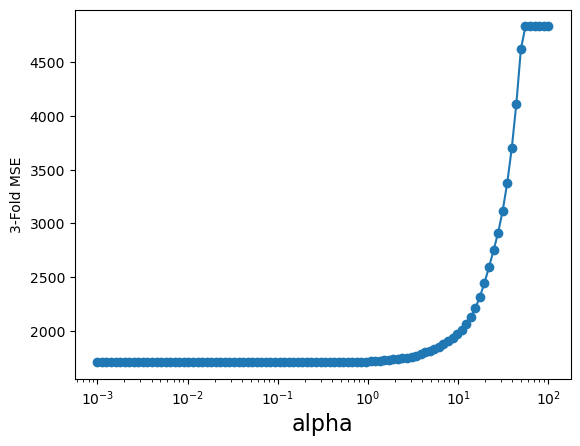

In [ ]:
alpha_vector = np.logspace(-3,2,100)
param_grid = {'alpha': alpha_vector }
grid = GridSearchCV(Lasso(random_state=0), scoring= 'neg_mean_squared_error', param_grid=param_grid, cv = 10, verbose=2)
grid.fit(XtrainScaled, y_train)
print("best mean cross-validation score: {:.3f}".format(grid.best_score_))
print("best parameters: {}".format(grid.best_params_))
scores = -1*np.array(grid.cv_results_['mean_test_score'])
plt.semilogx(alpha_vector,scores,'-o')
plt.xlabel('alpha',fontsize=16)
plt.ylabel('3-Fold MSE')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

alpha_optimo = grid.best_params_['alpha']
lasso = Lasso(alpha = alpha_optimo).fit(XtrainScaled,y_train)

ytrainLasso = lasso.predict(XtrainScaled)
ytestLasso  = lasso.predict(XtestScaled)

print("R² Train:", lasso.score(XtrainScaled, y_train))
print("R² Test: ", lasso.score(XtestScaled, y_test))


R² Train: 0.6510998315857086
R² Test:  0.64533587816101


## RIDGE
Es el modelo de regresión lineal con penalización sobre la magnitud de los coeficientes como medida contral el overfitting, **alpha (α)**
**Aplica una penalización ℓ2 (basada en el cuadrado de los coeficientes)**. Su objetivo es reducir la magnitud de todos los pesos, pero mantiene todas las variables en el modelo con valores pequeños, lo que lo hace muy robusto ante la correlación entre variables.
DATOS ESCALADOS.
**SU USO IDEAL ES CUANDO TIENES MUCHAS VARIABLES QUE ESTÁN CORRELACIONADAS ENTRE SI**

best parameters: {'alpha': np.float64(49.770235643321136)}


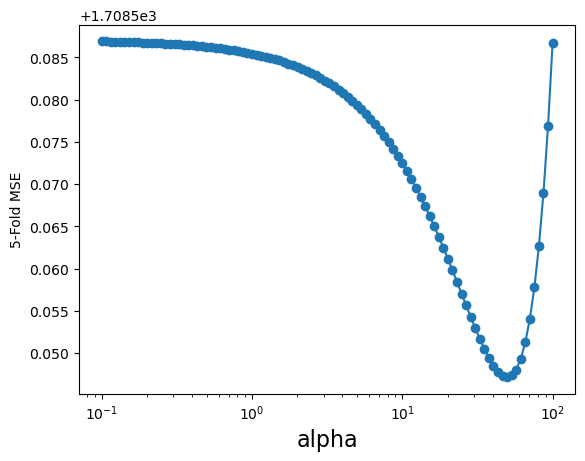

In [ ]:
#Utilizo validación cruzada para obtener el mejor valor de alpha.

alpha_vector = np.logspace(-1,2,100)
param_grid = {'alpha': alpha_vector }
grid = GridSearchCV(Ridge(), scoring= 'neg_mean_squared_error', param_grid=param_grid, cv = 8).fit(XtrainScaled, y_train)
print("best parameters: {}".format(grid.best_params_))

scores = -1*np.array(grid.cv_results_['mean_test_score'])
plt.semilogx(alpha_vector,scores,'-o')
plt.xlabel('alpha',fontsize=16)
plt.ylabel('5-Fold MSE')
plt.show()

In [ ]:
alpha_optimo = grid.best_params_['alpha']
ridge = Ridge(alpha = alpha_optimo).fit(XtrainScaled,y_train) 
print("R² Train:", ridge.score(XtrainScaled, y_train))
print("R² Test: ", ridge.score(XtestScaled, y_test))


R² Train: 0.6512705590451086
R² Test:  0.6451947112171327


## ALGORITMOS - ÁRBOLES DE DECISIÓN (Individuales y Ensamblados)

Segmentan el espacio de los datos en regiones más sencillas y no necesitan que escales tus variables

### A controlar:

1. **Profundidad** del árbol (*max_depth*):

    - Poca profundidad (poco complejo), menor riesgo de sufrir overfitting a costa de incurrir en más error de clasificación.

    - Mucha profundidad (muy complejo), mayor riesgo de sufrir overfitting a costa de mejorar el error de clasificación.

2. **Número mínimo de muestras en una hoja** (*min_samples_leaf*). Un árbol con un *min_samples_leaf* elevado, tendrá complejidad menor que un árbol con *min_samples_leaf* pequeño.

## Árbol de decisión invididual

Divide los datos mediante preguntas binarias y lo va a haciendo en regresión, es decir, predice el valor promedio de las muestras de esa región y avanza.
Es bueno para **datos con relaciones no lineales sencillas** pero si es muy profundo (controlar max_depth), tiende a generar Overfitting.

In [ ]:
maxDepth1 = range(2,12)
minSamplesLeaf1 = [1,5,10,20,50]
param_grid = {'max_depth': maxDepth1, 'min_samples_leaf':minSamplesLeaf1 }
grid1 = GridSearchCV(DecisionTreeRegressor(random_state=0), param_grid=param_grid, cv = 5,verbose=2)
grid1.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid1.best_score_))
print("best parameters: {}".format(grid1.best_params_))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END ....................max_depth=2, min_samples_leaf=1; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=1; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=1; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=1; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=1; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=5; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=5; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=5; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=5; total time=   0.0s
[CV] END ....................max_depth=2, min_samples_leaf=5; total time=   0.0s
[CV] END ...................max_depth=2, min_samples_leaf=10; total time=   0.0s
[CV] END ...................max_depth=2, min_sa

In [ ]:
maxDepthOptimo1 = grid1.best_params_['max_depth']
minSamplesLeafOptimo1 = grid1.best_params_['min_samples_leaf']
treeModel = DecisionTreeRegressor(max_depth=maxDepthOptimo1, min_samples_leaf=minSamplesLeafOptimo1).fit(X_train,y_train)
print("Train: ",treeModel.score(X_train,y_train))
print("Test: ",treeModel.score(X_test,y_test))

Train:  0.8362811554225706
Test:  0.79259908219541


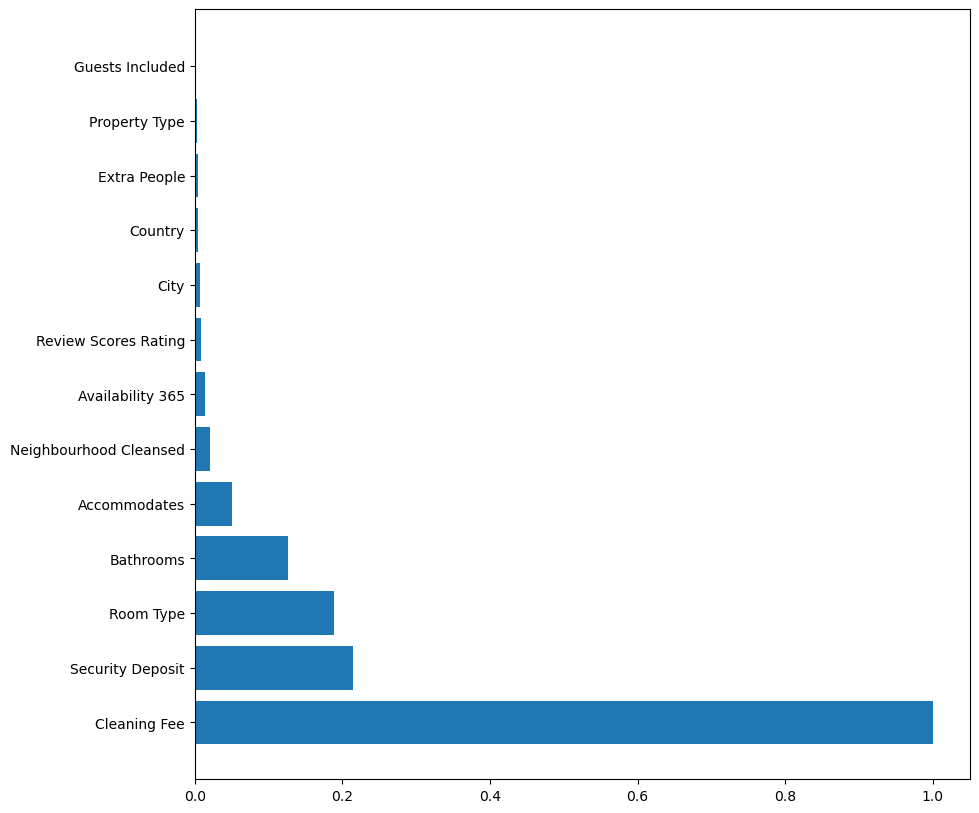

In [ ]:
importances = treeModel.feature_importances_
importances = importances / np.max(importances)
indices = np.argsort(importances)[::-1]
feature_names = np.array(airbnb_practica_train_final.columns[1:])
plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

## RANDOM FOREST

Es una versión mejorada de Bagging.

Al crear cada split en los árboles, solo se le permite elegir entre un subconjunto aleatorio de variables. Esto hace que los árboles sean diferentes entre sí (decorrelación).

**Es un algoritmo "todoterreno" muy robusto para datos tabulares heterogéneos**

In [ ]:
maxDepth2 = [3,5,7,10]
minSamplesLeaf2 = [5,10,20]
maxFeatures2 = [0.3,'sqrt','log2']
param_grid2 = {'max_depth': maxDepth2, 'min_samples_leaf':minSamplesLeaf2, 'max_features': maxFeatures2}
grid2 = GridSearchCV(RandomForestRegressor(random_state=0, n_estimators=200),param_grid=param_grid2,cv=5, verbose=2)
grid2.fit(X_train, y_train)
print("best score: {:.3f}".format(grid2.best_score_))
print("best params: {}".format(grid2.best_params_))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ..max_depth=3, max_features=0.3, min_samples_leaf=5; total time=   0.4s
[CV] END ..max_depth=3, max_features=0.3, min_samples_leaf=5; total time=   0.4s
[CV] END ..max_depth=3, max_features=0.3, min_samples_leaf=5; total time=   0.4s
[CV] END ..max_depth=3, max_features=0.3, min_samples_leaf=5; total time=   0.4s
[CV] END ..max_depth=3, max_features=0.3, min_samples_leaf=5; total time=   0.4s
[CV] END .max_depth=3, max_features=0.3, min_samples_leaf=10; total time=   0.4s
[CV] END .max_depth=3, max_features=0.3, min_samples_leaf=10; total time=   0.4s
[CV] END .max_depth=3, max_features=0.3, min_samples_leaf=10; total time=   0.4s
[CV] END .max_depth=3, max_features=0.3, min_samples_leaf=10; total time=   0.4s
[CV] END .max_depth=3, max_features=0.3, min_samples_leaf=10; total time=   0.4s
[CV] END .max_depth=3, max_features=0.3, min_samples_leaf=20; total time=   0.4s
[CV] END .max_depth=3, max_features=0.3, min_sa

In [ ]:
maxDepthOptimo2 = grid2.best_params_['max_depth']
minSamplesOptimo2 = grid2.best_params_['min_samples_leaf']
maxFeaturesOptimo2 = grid2.best_params_['max_features']
randomForest = RandomForestRegressor(max_depth=maxDepthOptimo2,n_estimators=200, min_samples_leaf=minSamplesOptimo2, max_features=maxFeaturesOptimo2).fit(X_train,y_train)
print("Train: ",randomForest.score(X_train,y_train))
print("Test: ",randomForest.score(X_test,y_test))

Train:  0.8496522900614706
Test:  0.8206561483102779


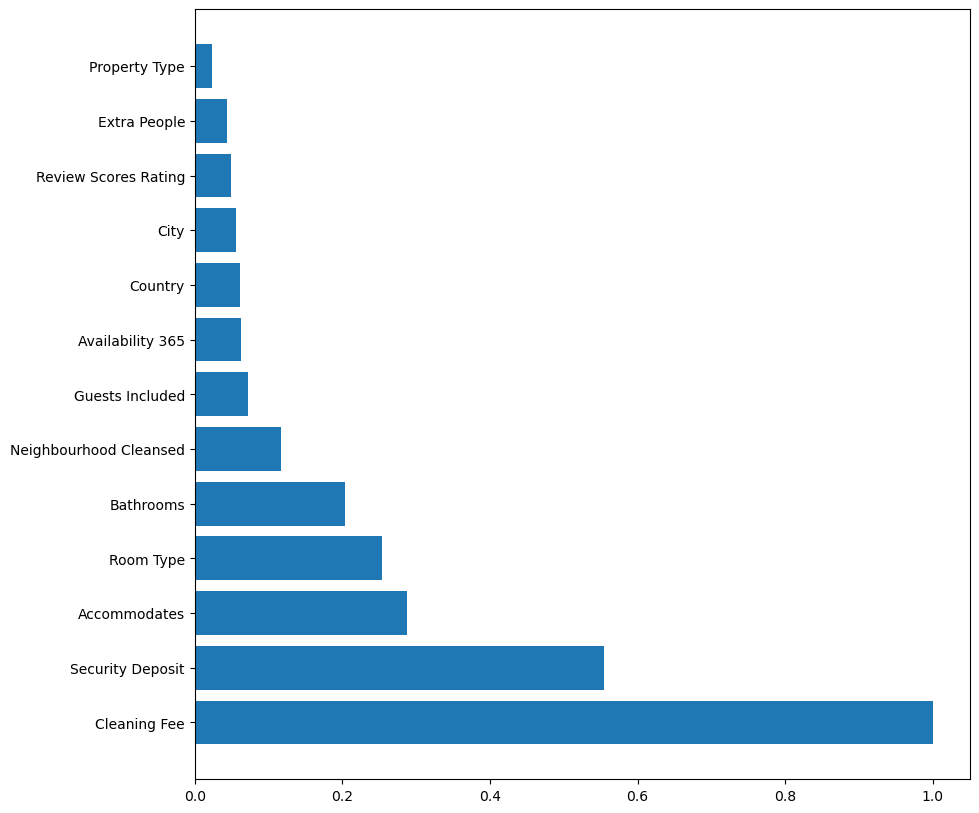

In [ ]:
importances = randomForest.feature_importances_
importances = importances / np.max(importances)
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

## BAGGING REGRESSOR

Entrena múltiples árboles de forma independiente y paralela sobre diferentes subconjuntos aleatorios de tus datos.
Promedia las predicciones de todos los árboles para reducir la varianza

In [ ]:
maxDepth3 = range(1,15)
tuned_parameters = {'estimator__max_depth': maxDepth3}
grid3 = GridSearchCV(BaggingRegressor(estimator=DecisionTreeRegressor(), random_state=0, n_estimators=200), param_grid=tuned_parameters,cv=5, verbose=2)
grid3.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid3.best_score_))
print("best parameters: {}".format(grid3.best_params_))

Fitting 5 folds for each of 14 candidates, totalling 70 fits
[CV] END .............................estimator__max_depth=1; total time=   0.5s
[CV] END .............................estimator__max_depth=1; total time=   0.5s
[CV] END .............................estimator__max_depth=1; total time=   0.5s
[CV] END .............................estimator__max_depth=1; total time=   0.5s
[CV] END .............................estimator__max_depth=1; total time=   0.5s
[CV] END .............................estimator__max_depth=2; total time=   0.9s
[CV] END .............................estimator__max_depth=2; total time=   0.9s
[CV] END .............................estimator__max_depth=2; total time=   0.9s
[CV] END .............................estimator__max_depth=2; total time=   0.9s
[CV] END .............................estimator__max_depth=2; total time=   0.9s
[CV] END .............................estimator__max_depth=3; total time=   1.3s
[CV] END .............................estimator_

In [ ]:
maxDepthOptimo3 = grid3.best_params_['estimator__max_depth']
baggingRegressor = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=maxDepthOptimo3),n_estimators=200).fit(X_train,y_train)
print("Train: ", baggingRegressor.score(X_train, y_train))
print("Test: ", baggingRegressor.score(X_test, y_test))

Train:  0.9587376847299759
Test:  0.8537819185961357


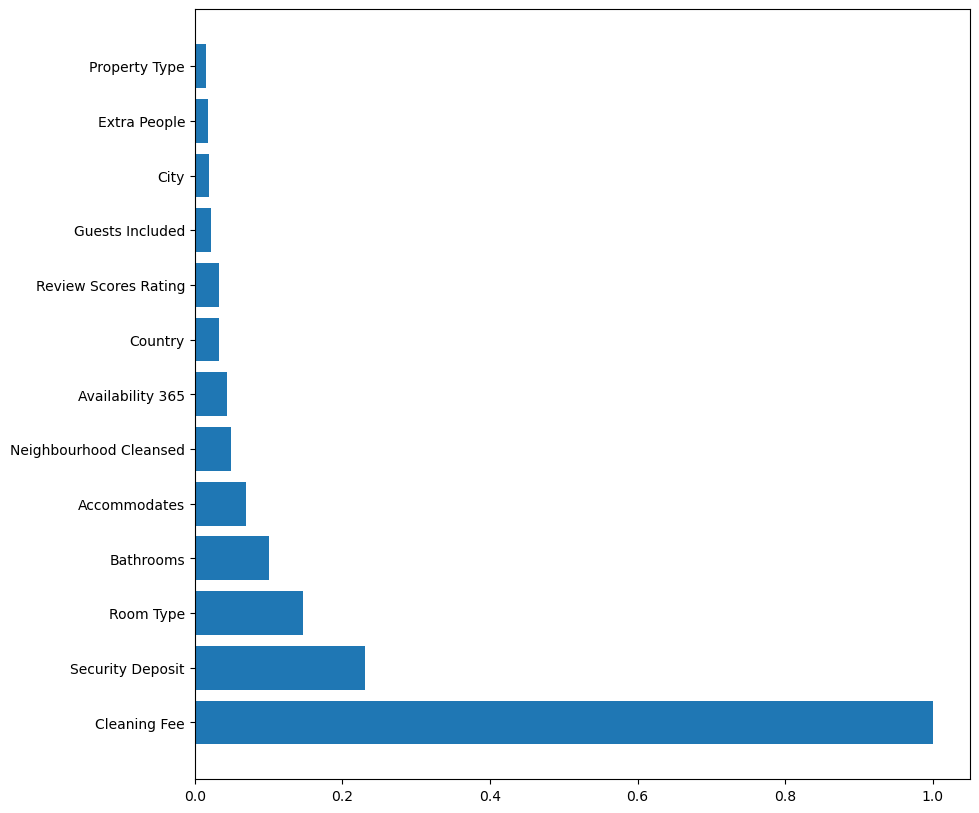

In [ ]:
importances = np.mean([tree.feature_importances_ for tree in baggingRegressor.estimators_], axis=0)
importances = importances / np.max(importances)
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

## BOOSTED TREES

Cada árbol nuevo se entrena específicamente para corregir los errores cometidos por los árboles anteriores.
XGBoost es una implementación optimizada y muy rápida de este proceso.
Al usar un learning_rate pequeño, aplicas shrinkage, una técnica de regularización que reduce la varianza y ayuda a que el modelo final sea más robusto
**Uso ideal: Cuando buscas la máxima precisión posible en problemas complejos**

In [ ]:
Niterations = [500,1000,1500,2000]
learningRate = [0.1,0.05]
param_grid = {'n_estimators': Niterations,'learning_rate':learningRate }
grid4 = GridSearchCV(GradientBoostingRegressor(random_state=0, max_depth=2, n_estimators=2000), param_grid=param_grid, cv=3, verbose=2)
grid4.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid4.best_score_))
print("best parameters: {}".format(grid4.best_params_))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ................learning_rate=0.1, n_estimators=500; total time=   2.5s
[CV] END ................learning_rate=0.1, n_estimators=500; total time=   2.5s
[CV] END ................learning_rate=0.1, n_estimators=500; total time=   2.5s
[CV] END ...............learning_rate=0.1, n_estimators=1000; total time=   5.2s
[CV] END ...............learning_rate=0.1, n_estimators=1000; total time=   5.2s
[CV] END ...............learning_rate=0.1, n_estimators=1000; total time=   5.3s
[CV] END ...............learning_rate=0.1, n_estimators=1500; total time=   8.1s
[CV] END ...............learning_rate=0.1, n_estimators=1500; total time=   8.2s
[CV] END ...............learning_rate=0.1, n_estimators=1500; total time=   7.8s
[CV] END ...............learning_rate=0.1, n_estimators=2000; total time=  10.5s
[CV] END ...............learning_rate=0.1, n_estimators=2000; total time=  10.5s
[CV] END ...............learning_rate=0.1, n_esti

In [ ]:
lrOptimo = grid4.best_params_['learning_rate']
neOptimo = grid4.best_params_['n_estimators']
Boosted = GradientBoostingRegressor(max_depth=2, n_estimators=neOptimo, learning_rate=lrOptimo).fit(X_train,y_train)
print("Train: ",Boosted.score(X_train,y_train))
print("Test: ",Boosted.score(X_test,y_test))

Train:  0.8900851901140978
Test:  0.8455433915673208


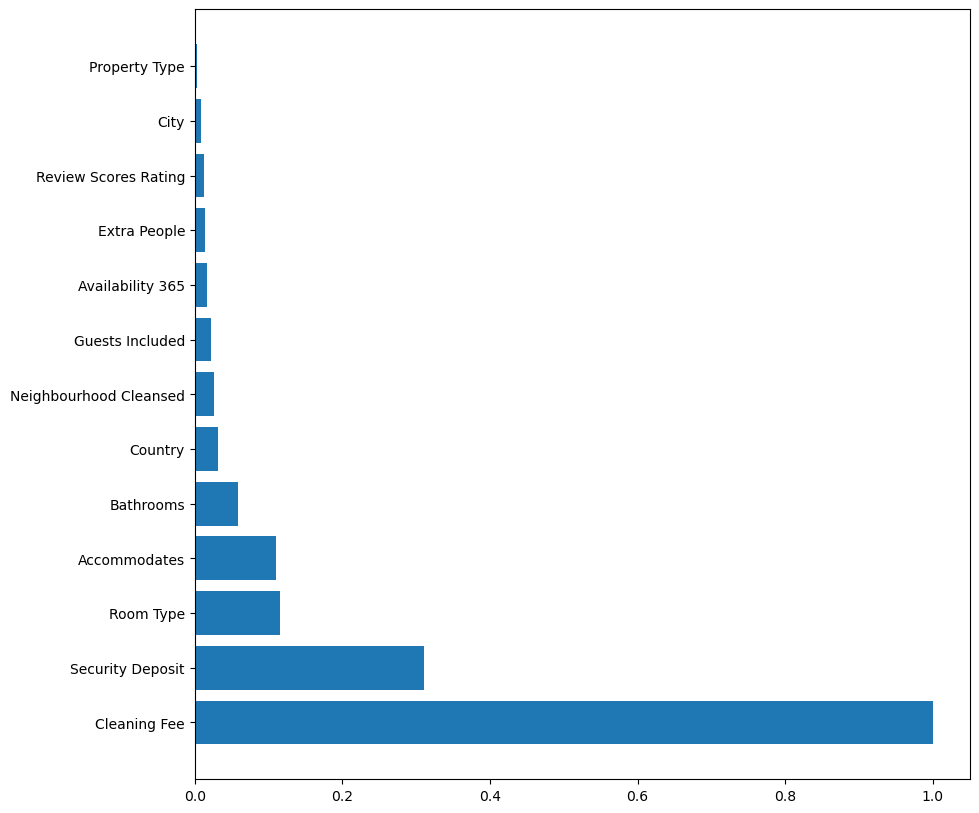

In [ ]:
importances = Boosted.feature_importances_
importances = importances / np.max(importances)
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,10))
plt.barh(range(X_train.shape[1]),importances[indices])
plt.yticks(range(X_train.shape[1]),feature_names[indices])
plt.show()

## XGBoost

Es una implementación optimizada y muy rápida del proceso Boosted.

In [ ]:
n_iterations = [500, 1000, 2000]
learning_rate = [0.1, 0.05]
param_grid5 = {'n_estimators': n_iterations,'learning_rate': learning_rate}
grid5 = GridSearchCV(XGBRegressor(random_state=0, max_depth=2), param_grid=param_grid5, cv=3, verbose=2)
grid5.fit(X_train, y_train)
print("best mean cross-validation score: {:.3f}".format(grid5.best_score_))
print("best parameters: {}".format(grid5.best_params_))

best_xgb = grid5.best_estimator_   
print("R² Train:", best_xgb.score(X_train, y_train))
print("R² Test: ", best_xgb.score(X_test, y_test))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ................learning_rate=0.1, n_estimators=500; total time=   0.0s
[CV] END ................learning_rate=0.1, n_estimators=500; total time=   0.0s
[CV] END ................learning_rate=0.1, n_estimators=500; total time=   0.0s
[CV] END ...............learning_rate=0.1, n_estimators=1000; total time=   0.1s
[CV] END ...............learning_rate=0.1, n_estimators=1000; total time=   0.1s
[CV] END ...............learning_rate=0.1, n_estimators=1000; total time=   0.1s
[CV] END ...............learning_rate=0.1, n_estimators=2000; total time=   0.3s
[CV] END ...............learning_rate=0.1, n_estimators=2000; total time=   0.3s
[CV] END ...............learning_rate=0.1, n_estimators=2000; total time=   0.3s
[CV] END ...............learning_rate=0.05, n_estimators=500; total time=   0.0s
[CV] END ...............learning_rate=0.05, n_estimators=500; total time=   0.0s
[CV] END ...............learning_rate=0.05, n_est

## SVMs

Es algo más compleja a nivel técnico. Busca un hiperplano que se ajuste a los datos dentro de un margen de tolerancia ajustable. Es el ejemplo en el cual "cambiando la dimensionalidad del problema" podía encontrarse una solución.
Se utilizaba el **"truco del kernel"** el cual permite calcular la similitud entre datos en espacios de alta dimensionalidad para capturar patrones no lineales sin un coste computacional excesivo.

**LOS PARÁMETROS CLAVE SON:** C (coste de penalización de errores) y gamma (influencia de cada muestra)

**REQUIERE ESCALADO OBLIGATORIO DE DATOS**

In [ ]:
from sklearn.svm import SVR

# He puesto esto vectores ya que sino, tardaba horas en ejecutarse...:
vectorC = np.logspace(-2, 4, 4)
vectorG = np.logspace(-2, 1, 4)

param_grid6 = {'C': vectorC, 'gamma':vectorG}
grid6 = GridSearchCV(SVR(kernel='rbf'), param_grid=param_grid6, cv = 5, verbose=2)
grid6.fit(XtrainScaled, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .................................C=0.01, gamma=0.01; total time=   4.0s
[CV] END .................................C=0.01, gamma=0.01; total time=   4.0s
[CV] END .................................C=0.01, gamma=0.01; total time=   4.0s
[CV] END .................................C=0.01, gamma=0.01; total time=   4.0s
[CV] END .................................C=0.01, gamma=0.01; total time=   4.0s
[CV] END ..................................C=0.01, gamma=0.1; total time=   4.0s
[CV] END ..................................C=0.01, gamma=0.1; total time=   4.0s
[CV] END ..................................C=0.01, gamma=0.1; total time=   4.0s
[CV] END ..................................C=0.01, gamma=0.1; total time=   3.9s
[CV] END ..................................C=0.01, gamma=0.1; total time=   4.0s
[CV] END ..................................C=0.01, gamma=1.0; total time=   3.8s
[CV] END ..................................C=0.0

,estimator,SVR()
,param_grid,"{'C': array([1.e-02...e+02, 1.e+04]), 'gamma': array([ 0.01,... 1. , 10. ])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'rbf'


In [ ]:
print("best mean cross-validation score: {:.3f}".format(grid6.best_score_))
print("best parameters: {}".format(grid6.best_params_))

print("Gamma en la gráfica: ", np.log10(grid6.best_params_['gamma']))
print("C en la gráfica: ", np.log10(grid6.best_params_['C']))

scores = grid6.cv_results_['mean_test_score'].reshape(len(vectorC),len(vectorG))


best mean cross-validation score: 0.755
best parameters: {'C': np.float64(10000.0), 'gamma': np.float64(0.01)}
Gamma en la gráfica:  -2.0
C en la gráfica:  4.0


In [ ]:
# Paso 3:
Copt = grid6.best_params_['C']
Gopt = grid6.best_params_['gamma']

svmModel = SVR(kernel='rbf',gamma = Gopt, C = Copt).fit(XtrainScaled,y_train)
print(f'Acc (TRAIN): {svmModel.score(XtrainScaled,y_train):0.2f}')
print(f'Acc (TEST): {svmModel.score(XtestScaled,y_test):0.2f}')

Acc (TRAIN): 0.86
Acc (TEST): 0.75


# TABLA COMPARATIVA

In [ ]:
def get_metrics(model, X_train, y_train, X_test, y_test):
    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test, y_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    rmse_test  = np.sqrt(mean_squared_error(y_test,  model.predict(X_test)))
    return r2_train, r2_test, rmse_train, rmse_test

modelos = {
    'Lasso':         (lasso,            XtrainScaled, XtestScaled),
    'Ridge':         (ridge,            XtrainScaled, XtestScaled),
    'Decision Tree': (treeModel,        X_train,      X_test),
    'Random Forest': (randomForest,     X_train,      X_test),
    'Bagging':       (baggingRegressor, X_train,      X_test),
    'GBM':           (Boosted,          X_train,      X_test),
    'XGboost':       (best_xgb,        X_train,      X_test),
    'SVR':           (svmModel,         XtrainScaled, XtestScaled)
}

filas = []
for nombre, (modelo, Xtr, Xte) in modelos.items():
    r2_tr, r2_te, rmse_tr, rmse_te = get_metrics(modelo, Xtr, y_train, Xte, y_test)
    filas.append({
        'Modelo':        nombre,
        'R² Train':      r2_tr,
        'R² Test':       r2_te,
        'ΔR² (overfit)': r2_tr - r2_te,
        'RMSE Train':    rmse_tr,
        'RMSE Test':     rmse_te
    })

resultados = pd.DataFrame(filas).sort_values('R² Test', ascending=False).reset_index(drop=True)
resultados = resultados.round(4)
resultados.style \
    .highlight_max(subset=['R² Test'],       color='lightgreen') \
    .highlight_min(subset=['RMSE Test'],     color='lightgreen') \
    .highlight_max(subset=['ΔR² (overfit)'], color='salmon')



,Modelo,R² Train,R² Test,ΔR² (overfit),RMSE Train,RMSE Test
0,Bagging,0.958700,0.853800,0.105000,14.116900,26.441000
1,GBM,0.890100,0.845500,0.044500,23.040500,27.175700
2,XGboost,0.891800,0.845500,0.046200,22.862800,27.176100
3,Random Forest,0.849700,0.820700,0.029000,26.947100,29.283400
4,Decision Tree,0.836300,0.792600,0.043700,28.119800,31.490800
5,SVR,0.858100,0.747700,0.110400,26.182400,34.732300
6,Lasso,0.651100,0.645300,0.005800,41.050000,41.180000
7,Ridge,0.651300,0.645200,0.006100,41.040000,41.188200


## CONCLUSIÓN

### Modelos lineales (Lasso / Ridge):

Tienen un rendimiento modesto, por lo que podemos decir que la relación entre las features y la variable objetivo no se puede ajustar bien a una relación lineal. A cambio de esto, podemos ver que no existe prácticamente Overfitting. RESULTADO MODESTO PERO FIABLE.

### Modelos basados en árboles:

GBM es el modelo más recomendable en cuanto a métricas se refiere, seguido muy de cerca por XGBoost. GMB, tiene el mejor equilibrio entre rendimiento (R² test = 0.845) y generalización (ΔR² = 0.044). **En la práctica sería la primera elección.**
Luego iría Random Forest y Decision Tree ya que Bagging tiene claro Overfitting (probablemente podría retocar algo el modelo o los parámetros). 

### Modelo SVM:

Presenta overfitting sin embargo es por los parámetros que le he definido (con los "habituales" llevaba ejecutándose 2h...)